# Control de calidad utilizando LLaVa cuantizada en 4 bits

https://huggingface.co/llava-hf/llava-v1.6-mistral-7b-hf

In [1]:
# Algunas cosas que necesitamos antes de empezar
# Recordemos que esto corre en una T4. En CPU no puede cargar el modelo cuantizado
# --> entonces explota
!pip install -q -U transformers==4.37.2
!pip install -q bitsandbytes==0.41.3 accelerate==0.25.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.6/92.6 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.7/265.7 kB 19.2 MB/s eta 0:00:00


In [ ]:
# ==============================
# 1. PyTorch / Transformers (modelo)
# ==============================
import torch
from transformers import BitsAndBytesConfig, pipeline

# ==============================
# 2. Visión (imágenes y display)
# ==============================
import requests
from PIL import Image
from matplotlib import pyplot as plt

# ==============================
# 3. Dataset utilities (filesystem)
# ==============================
import random
from glob import glob
from pathlib import Path
import zipfile
import shutil

# ==============================
# 4. Google Colab utilities (opcional)
# ==============================
from google.colab import drive, userdata

In [ ]:
drive.mount('/content/drive')

# Esto es válido solo para mí, porque los datos los tengo almacenados en este directorio de Google Drive
carpeta_trabajo = '/content/drive/MyDrive/Vision Grado/TP Coloquios/Inspección de etiquetas'

# Copio los datos de entrenamiento a la carpeta local para que vuele!
shutil.copytree(carpeta_trabajo+'/dataset', '/content/dataset')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/dataset'

In [4]:
# Cargo el modelo desde hugginface utilizando una cuantización en 4 bits!
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16
)

model_id = "llava-hf/llava-1.5-7b-hf"
pipe = pipeline("image-to-text", model=model_id, model_kwargs={"quantization_config": quantization_config})

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/70.1k [00:00<?, ?B/s]

model-00001-of-00003.safetensors:   0%|          | 0.00/4.99G [00:00<?, ?B/s]

model-00002-of-00003.safetensors:   0%|          | 0.00/4.96G [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/41.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

(375, 500)


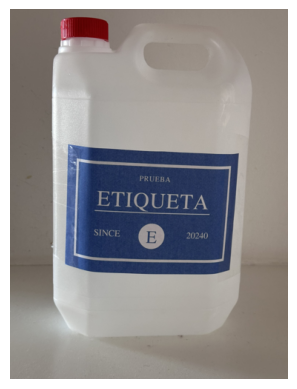

USER:  
As a manufacturer of this product, what aspects should I take care of in terms of appearance so that the consumer has the best impression?
ASSISTANT: As a manufacturer of this water bottle, you should focus on the product's appearance to create a positive impression on the consumer. Some aspects to consider include:

1. Cleanliness: Ensure that the bottle is clean and free of any dirt, stains, or contaminants.

2. Labeling: The labeling should be clear, easy to read, and visually appealing. In the image, the labeling is in Spanish, which might be a concern for some consumers.

3. Design: The bottle's design should be aesthetically pleasing and visually appealing. This can include the shape, color, and texture of the bottle.

4. Quality: The bottle should be made of high-quality materials and should be durable and long-lasting.

5. Branding: If you have a brand, ensure that the bottle's design and labeling reflect your brand's identity and values.

By taking care of these aspect

In [22]:
# Le pido al modelo que describa cuáles son los aspectos a ver en el control de calidad de este producto
#image = Image.open('/content/dataset/test/IMG_3852.JPEG')
image = Image.open('/content/dataset/productoOk/IMG_3871.JPEG')
# Redimensionar la imagen (mantiene la relación de aspecto)
image.thumbnail((500,500))
print(image.size)

plt.imshow(image)
plt.axis('off')
plt.show()

prompt = "USER: <image>\nAs a manufacturer of this product, what aspects should I take care of in terms of appearance so that the consumer has the best impression?\nASSISTANT:"
outputs = pipe(image, prompt=prompt, generate_kwargs={"max_new_tokens": 500})
print(outputs[0]["generated_text"])

In [20]:
# Voy a procesar el batch de imagenes buenas y malas
image_paths = glob('dataset/**/*.*', recursive=True)

N_images = 20
random_images = random.sample(image_paths, N_images)
for i in range(N_images):
  image = Image.open(random_images[i])
  plt.imshow(image)
  plt.axis('off')
  plt.show()

  prompt = "USER: <image>\nIs the blue label properly attached to the drum and in perfect condition?\nASSISTANT:"
  outputs = pipe(image, prompt=prompt, generate_kwargs={"max_new_tokens": 200})
  print(outputs[0]["generated_text"])

  prompt = "USER: <image>\nIs the red cap placed on the drum?\nASSISTANT:"
  outputs = pipe(image, prompt=prompt, generate_kwargs={"max_new_tokens": 200})
  print(outputs[0]["generated_text"])


Output hidden; open in https://colab.research.google.com to view.